In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from pydantic import BaseModel, Field
from typing import List, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
class ChatState(BaseModel):
    messages: Annotated[list, add_messages]

In [4]:
llm = ChatGroq(model="openai/gpt-oss-20b") 

In [5]:
def chatBotNode(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [6]:
memory = InMemorySaver()

In [10]:
graph = StateGraph(ChatState)
graph.add_node("chatBot", chatBotNode)

graph.add_edge(START, "chatBot")
graph.add_edge("chatBot", END)

finalGraph = graph.compile(checkpointer = InMemorySaver())

config = {"configurable": {"thread_id": 1}}

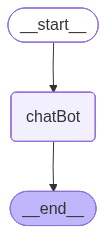

In [11]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())

In [13]:
res = finalGraph.invoke(
    {"messages": [{"role":"user", "content":"Hi How are you? My name is Hasan442"}]},
             config
             )

In [17]:
res["messages"][-1].content

'Hello Hasan442! I’m doing great—thanks for asking. How can I assist you today?'